In [1]:
import sys
from pathlib import Path
import country_converter as coco
import matplotlib.pyplot as plt
import re
import pandas as pd
import math
import numpy as np
from uncertainties import ufloat, nominal_value, std_dev
from uncertainties.core import CallableStdDev

# ---------------------------- Run from Repo Root ----------------------------
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# ---------------------------- File Paths ----------------------------
output_path = BASE_DIR / "results" / "Scale_up_output_MS.csv"
ecw_country = BASE_DIR / "results" / "ECWbyCountry.csv"
ecw_region = BASE_DIR / "results" / "ECWbyRegion.csv"

In [2]:
# ---------- Core Functions ----------

def get_series(df, region):
    """Return time (weeks), nominal values, and uncertainties for a single country."""
    if region not in df.index:
        raise ValueError(f"{region} not found in DataFrame index")

    row = df.loc[region]  # Series of ufloats
    row = row.iloc[2:]
    time = np.arange(len(row))
    values = np.array([nominal_value(v) for v in row])
    errors = np.array([std_dev(v) for v in row])
    return time, values, errors

def get_ECW(df, region):
    row = df.loc[region]
    ECW_Upper = row[1]
    ECW_Lower = row[0]
    return ECW_Lower, ECW_Upper

def plot_region(df, region, ax=None, sigma=1):
    """Plot a single country's series with ±sigma bands."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t, vals, errs = get_series(df, region)

    ecw_lower, ecw_upper = get_ECW(df, region)
    CADR_lower = CADRPP*ecw_lower
    CADR_upper = CADRPP*ecw_upper

    ax.axhspan(CADR_lower, CADR_upper, alpha=0.15, 
        label=f'CADR Range ({CADR_lower:.1f}-{CADR_upper:.1f})')
    
    ax.plot(t, vals, label=region)
    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, alpha=0.3)
    ax.set_title(f"{region} Scale Up with ±{sigma}σ bands ")
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax

def plot_multiple_regions(df, region, sigma=1):
    """Plot multiple countries together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for c in region:
        plot_region(df, c, ax=ax, sigma=sigma)
    plt.title(f"Multiple Regions series with ±{sigma}σ bands")
    plt.show()


In [3]:
## ---------------------------- Varaibles ---------------------------- 

CADRPP = 50 # L/s
UNRegion_list = ['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']

[0.00000000e+00 8.47007314e+06 2.04905580e+08 2.14585664e+08
 2.34576969e+08 2.45467063e+08 2.56962162e+08 2.69062267e+08
 2.81162371e+08 2.93262476e+08 3.05362580e+08 3.17462685e+08
 3.29562789e+08 3.41662894e+08 3.53762998e+08 3.65863103e+08
 3.77963207e+08 3.90063312e+08 4.02163416e+08 4.14263520e+08
 4.26363625e+08 4.38463729e+08 4.50563834e+08 4.62663938e+08
 4.74764043e+08 4.86864147e+08 4.98964252e+08 5.11064356e+08
 5.23164461e+08 5.35264565e+08 5.47364670e+08 5.59464774e+08
 5.71564879e+08 5.83664983e+08 5.95765088e+08 6.07865192e+08
 6.19965297e+08 6.32065401e+08 6.44165506e+08 6.56265610e+08
 6.68365715e+08 6.80465819e+08 6.92565924e+08 7.04666028e+08
 7.16766133e+08 7.28866237e+08 7.40966342e+08 7.53066446e+08
 7.65166550e+08 7.77266655e+08 7.89366759e+08 8.01466864e+08
 8.13566968e+08]


<Axes: title={'center': 'Germany Scale Up with ±2σ bands '}, xlabel='Weeks', ylabel='Value'>

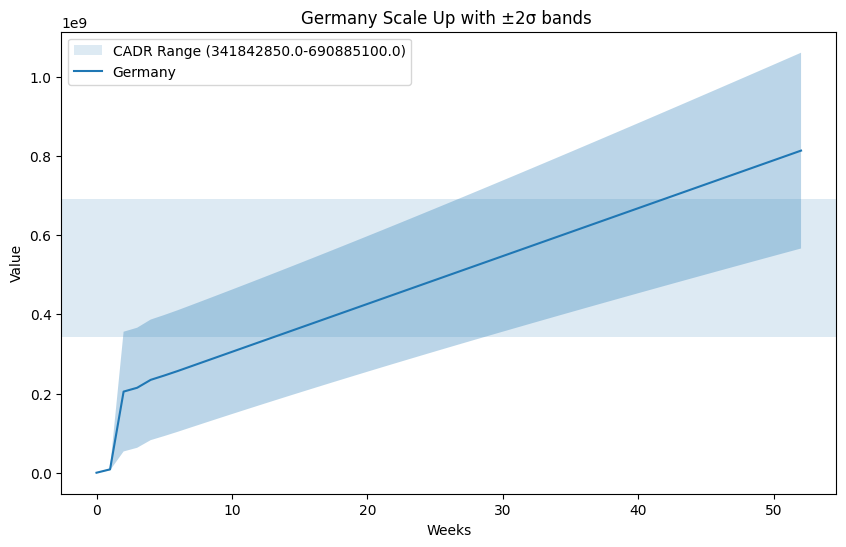

In [5]:
## ---------------------------- Scale Up Plotting for Tester ---------------------------- 
df_loaded = pd.read_pickle(output_path.with_suffix(".pkl"))

print(get_series(df_loaded, 'Germany')[1])

plot_region(df_loaded, "Germany", sigma=2)

# plot_multiple_regions(df_loaded, ["Eastern Asia", "Northern America", "Northern Europe"], sigma =2)

# for i in UNRegion_list:
#     plot_region(df_loaded, i, sigma=1)
